# Grid descriptors

Every operator in `torch-harmonics` takes a *grid descriptor* rather than a resolution and a grid name. A descriptor is a small, immutable object that knows where its nodes sit on the sphere and everything that follows from that:

* the node coordinates and the quadrature weights,
* the shape a field on the grid has,
* the largest degree a spherical harmonic transform (SHT) can be truncated to without losing orthogonality,
* the node spacing that localized operators take their default cutoff from,
* how the grid is split across ranks for distributed computation.

This notebook walks through how to build descriptors, what they know, and how layers use them. It also generates the grid figure in the README.

## Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import torch_harmonics as th

## Building a descriptor

Each grid type has its own class. The latitude-longitude grids are described by the number of rings `nlat` and the number of points per ring `nlon`, while HEALPix is described by its resolution parameter `nside`:

In [2]:
grid = th.LegendreGaussGrid(nlat=16, nlon=32)
hp = th.HealpixGrid(nside=4)
print(repr(grid))
print(repr(hp))

LegendreGaussGrid(nlat=16, nlon=32)
HealpixGrid(nside=4)


Alternatively, `th.as_grid` builds a descriptor from the name of its grid type, which is convenient when the grid type comes from a configuration file. `th.grid_types` and `th.grid_params` list the names and the parameters each grid type takes:

In [3]:
for grid_type in th.grid_types():
    print(f"{grid_type:16s} {th.grid_params(grid_type)}")

print(th.as_grid("legendre-gauss", nlat=16, nlon=32) == grid)

equiangular      ('nlat', 'nlon')
legendre-gauss   ('nlat', 'nlon')
lobatto          ('nlat', 'nlon')
trapezoidal      ('nlat', 'nlon')
healpix          ('nside',)
True


Passing an existing descriptor to `as_grid` returns it unchanged, so a function can accept either a descriptor or a name:

In [4]:
print(th.as_grid(grid) is grid)

True


## What a descriptor knows

The node positions are given as colatitudes $\theta \in [0, \pi]$ per ring and longitudes $\varphi \in [0, 2\pi)$ within each ring. The quadrature weights `quad_weights` hold one entry per point and sum to $4\pi$, the area of the unit sphere:

In [5]:
print("shape:          ", grid.shape)
print("npoints:        ", grid.npoints)
print("nrings:         ", grid.nrings)
print("colats[:4]:     ", grid.colats[:4])
print("lons(0)[:4]:    ", grid.lons(0)[:4])
print("coords.shape:   ", grid.coords.shape)
print("quad_weights:   ", grid.quad_weights.shape, float(grid.quad_weights.sum()), 4 * np.pi)

shape:           (16, 32)
npoints:         512
nrings:          16
colats[:4]:      tensor([0.1457, 0.3345, 0.5244, 0.7145], dtype=torch.float64)
lons(0)[:4]:     tensor([0.0000, 0.1963, 0.3927, 0.5890], dtype=torch.float64)
coords.shape:    torch.Size([512, 2])
quad_weights:    torch.Size([512]) 12.56637061435917 12.566370614359172


The descriptors also report properties that depend on how the nodes are placed. `max_exact_degree` is the largest degree an SHT on the grid can be truncated to while keeping the associated Legendre functions discretely orthogonal. `is_spectrally_accurate` reports whether the quadrature converges faster than any power of the resolution. `max_latitude_spacing` is the largest gap between adjacent rings, which is used for the default cutoff radius of localized operators such as DISCO convolutions and neighborhood attention.

Comparing the latitude-longitude grids at the same number of rings shows the differences:

In [6]:
print(f"{'grid':16s} {'max_exact_degree':>16s} {'spectral':>9s} {'max dtheta':>11s}")
for grid_type in ["equiangular", "legendre-gauss", "lobatto", "trapezoidal"]:
    g = th.as_grid(grid_type, nlat=17, nlon=32)
    print(f"{grid_type:16s} {g.max_exact_degree:16d} {str(g.is_spectrally_accurate):>9s} {g.max_latitude_spacing:11.4f}")

grid             max_exact_degree  spectral  max dtheta
equiangular                     9      True      0.1963
legendre-gauss                 17      True      0.1794
lobatto                        16      True      0.2323
trapezoidal                     9     False      0.5054


Legendre-Gauss supports the highest degree for a given number of rings. The trapezoidal grid is not spectrally accurate, so it should only be used for an SHT at a low bandlimit.

## The supported grids

The figure below shows all supported grids at coarse resolution, both on the sphere and in longitude-latitude coordinates. All information needed for the plot comes from the descriptor: the colatitude of each ring and the longitudes on that ring.

In [7]:
def grid_lonlat(grid):
    # longitude and latitude of every node, in degrees, ring by ring
    lons, lats = [], []
    for ring, colat in enumerate(grid.colats.tolist()):
        lon = np.rad2deg(grid.lons(ring).double().numpy())
        lons.append(lon)
        lats.append(np.full_like(lon, 90.0 - np.rad2deg(colat)))
    lons, lats = np.concatenate(lons), np.concatenate(lats)
    return (lons + 180.0) % 360.0 - 180.0, lats


grids = {
    "Equiangular": th.EquiangularGrid(nlat=17, nlon=32),
    "Legendre-Gauss": th.LegendreGaussGrid(nlat=16, nlon=32),
    "Lobatto": th.LobattoGrid(nlat=17, nlon=32),
    "Trapezoidal": th.TrapezoidalGrid(nlat=17, nlon=32),
    "HEALPix": th.HealpixGrid(nside=6),
}

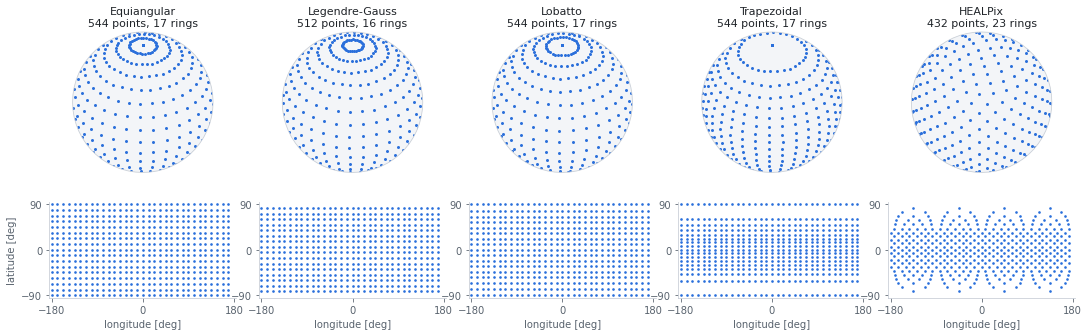

In [8]:
ink, muted, edge, accent = "#1f2328", "#59636e", "#c8ced6", "#2a6fdb"
plt.rcParams.update({"font.size": 10, "text.color": ink, "axes.labelcolor": muted, "xtick.color": muted, "ytick.color": muted})

fig = plt.figure(figsize=(15, 5.0), facecolor="white")
for i, (name, grid) in enumerate(grids.items()):
    lons, lats = grid_lonlat(grid)

    # on the sphere
    ax = fig.add_subplot(2, 5, i + 1, projection=ccrs.Orthographic(central_longitude=-20, central_latitude=35))
    ax.set_global()
    ax.add_patch(plt.Circle((0, 0), 6.371e6, transform=ax.transData, facecolor="#f3f5f8", edgecolor="none", zorder=0))
    ax.spines["geo"].set_edgecolor(edge)
    ax.scatter(lons, lats, s=9, color=accent, transform=ccrs.PlateCarree(), zorder=2, linewidths=0)
    ax.set_title(f"{name}\n{grid.npoints} points, {grid.nrings} rings", fontsize=11)

    # in longitude-latitude coordinates
    ax = fig.add_subplot(2, 5, i + 6)
    ax.scatter(lons, lats, s=7, color=accent, linewidths=0)
    ax.set_xlim(-185, 185)
    ax.set_ylim(-95, 95)
    ax.set_xticks([-180, 0, 180])
    ax.set_yticks([-90, 0, 90])
    ax.set_aspect("equal")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(edge)
    ax.set_xlabel("longitude [deg]")
    if i == 0:
        ax.set_ylabel("latitude [deg]")

fig.subplots_adjust(left=0.04, right=0.99, top=0.9, bottom=0.1, hspace=0.05, wspace=0.12)
fig.savefig("../images/grids.png", dpi=110, facecolor="white")
plt.show()

The equiangular, Legendre-Gauss and Lobatto grids are hard to tell apart in longitude-latitude coordinates, but on the sphere the nodes crowd together near the poles. The trapezoidal grid spaces its rings equally in $\cos\theta$, which places most of them near the equator. HEALPix is the only grid whose nodes cover the sphere uniformly.

### Quadrature weights

The latitudinal quadrature weights `colat_weights` show the same differences. They integrate over $\cos\theta \in [-1, 1]$ and therefore sum to 2:

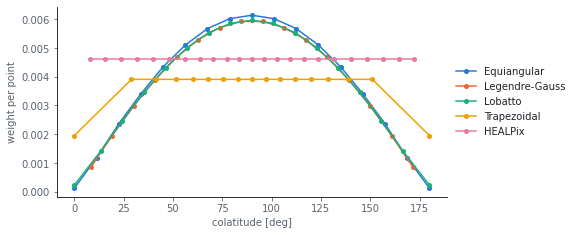

In [9]:
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

fig, ax = plt.subplots(figsize=(7, 3.5))
for color, (name, grid) in zip(colors, grids.items()):
    weights = grid.colat_weights.double().numpy() / grid.nlon_per_lat.double().numpy()
    ax.plot(np.rad2deg(grid.colats.double().numpy()), weights, "-o", ms=4, lw=1.5, color=color, label=name)
ax.set_xlabel("colatitude [deg]")
ax.set_ylabel("weight per point")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

Here the ring weights are divided by the number of points on each ring, so the plot shows the area each point represents. On the latitude-longitude grids, points near the poles represent much less area than points at the equator. On HEALPix, every point represents the same area.

## Ragged grids: HEALPix

The rings of a HEALPix grid hold different numbers of points: 4 at the poles and up to `4 * nside` at the equator. A field on a HEALPix grid therefore cannot be stored as `(nlat, nlon)`. Instead, it is stored as a flat tensor of shape `(..., npix)` in RING order, meaning ring by ring from the north pole and by increasing longitude within a ring. `nlon_per_lat` and `lon_offsets` describe this layout:

In [10]:
hp = th.HealpixGrid(nside=2)
print("shape:        ", hp.shape)
print("nlon_per_lat: ", hp.nlon_per_lat.tolist())
print("lon_offsets:  ", hp.lon_offsets.tolist())
print("is_regular:   ", hp.is_regular)
print("equal area:   ", hp.is_equal_area)

shape:         (48,)
nlon_per_lat:  [4, 8, 8, 8, 8, 8, 4]
lon_offsets:   [0, 4, 12, 20, 28, 36, 44, 48]
is_regular:    False
equal area:    True


A ring of a flat field is a contiguous slice between consecutive offsets:

In [11]:
field = torch.arange(hp.npoints)
offsets = hp.lon_offsets.tolist()
for ring in range(hp.nrings):
    print(ring, field[offsets[ring]:offsets[ring + 1]].tolist())

0 [0, 1, 2, 3]
1 [4, 5, 6, 7, 8, 9, 10, 11]
2 [12, 13, 14, 15, 16, 17, 18, 19]
3 [20, 21, 22, 23, 24, 25, 26, 27]
4 [28, 29, 30, 31, 32, 33, 34, 35]
5 [36, 37, 38, 39, 40, 41, 42, 43]
6 [44, 45, 46, 47]


The regular grids report the same structure, with a constant number of points per ring. Code written in terms of `nlon_per_lat` and `lon_offsets` therefore works on all grids.

## Using descriptors in layers

Layers take the descriptor as their first argument. The simplest example is `QuadratureS2`, which integrates a field over the sphere using the descriptor's quadrature weights. Integrating a constant gives the area of the sphere, $4\pi$, on every grid:

In [12]:
for name, grid in grids.items():
    quadrature = th.QuadratureS2(grid)
    print(f"{name:16s} {float(quadrature(torch.ones(grid.shape))):.5f}  (4 pi = {4 * np.pi:.5f})")

Equiangular      12.56637  (4 pi = 12.56637)
Legendre-Gauss   12.56637  (4 pi = 12.56637)
Lobatto          12.56637  (4 pi = 12.56637)
Trapezoidal      12.56637  (4 pi = 12.56637)
HEALPix          12.56637  (4 pi = 12.56637)


How accurate the integral is depends on the grid. As a test function we use $f = e^{\cos\theta}$, whose integral is $2\pi(e - e^{-1})$. `QuadratureS2` stores its weights in single precision, so to see how each grid's quadrature converges down to double precision, we use the descriptor's `quad_weights` directly. Integrating at increasing resolution gives:

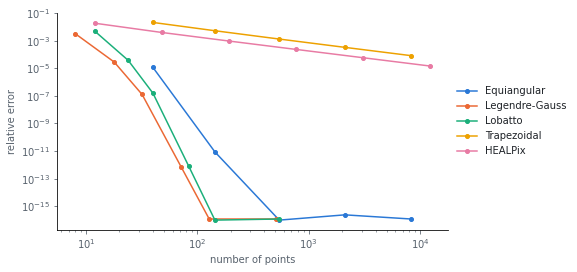

In [13]:
exact = 2 * np.pi * (np.e - 1 / np.e)


def integration_error(grid):
    colats = grid.coords[:, 0]
    f = torch.exp(torch.cos(colats))
    return abs(float(torch.sum(f * grid.quad_weights)) - exact) / exact


resolutions = {
    "Equiangular": [th.EquiangularGrid(nlat=n + 1, nlon=2 * n) for n in [4, 8, 16, 32, 64]],
    "Legendre-Gauss": [th.LegendreGaussGrid(nlat=n, nlon=2 * n) for n in [2, 3, 4, 6, 8, 16]],
    "Lobatto": [th.LobattoGrid(nlat=n + 1, nlon=2 * n) for n in [2, 3, 4, 6, 8, 16]],
    "Trapezoidal": [th.TrapezoidalGrid(nlat=n + 1, nlon=2 * n) for n in [4, 8, 16, 32, 64]],
    "HEALPix": [th.HealpixGrid(nside=n) for n in [1, 2, 4, 8, 16, 32]],
}

fig, ax = plt.subplots(figsize=(7, 4))
for color, (name, grids_at_res) in zip(colors, resolutions.items()):
    npoints = [g.npoints for g in grids_at_res]
    errors = [max(integration_error(g), 1e-16) for g in grids_at_res]
    ax.loglog(npoints, errors, "-o", ms=4, lw=1.5, color=color, label=name)
ax.set_xlabel("number of points")
ax.set_ylabel("relative error")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

The Gaussian grids reach machine precision with very few points and the equiangular grid follows shortly after, while the trapezoidal and HEALPix grids converge only algebraically. Errors below $10^{-16}$ are clipped for plotting.

The SHT reads its default truncation from the descriptor:

In [14]:
import warnings

for grid_type in ["equiangular", "legendre-gauss"]:
    grid = th.as_grid(grid_type, nlat=32, nlon=64)
    with warnings.catch_warnings():
        # the equiangular default changed in v0.9.0 and warns about it
        warnings.simplefilter("ignore")
        sht = th.RealSHT(grid)
    print(f"{grid_type:16s} max_exact_degree={grid.max_exact_degree} lmax={sht.lmax} mmax={sht.mmax}")

equiangular      max_exact_degree=16 lmax=16 mmax=16
legendre-gauss   max_exact_degree=32 lmax=32 mmax=32


Layers that map between two grids take `grid_in` and `grid_out`, which may be different grid types. For example, `ResampleS2` interpolates between two latitude-longitude grids, and `AttentionS2` can decode from HEALPix onto a latitude-longitude grid:

In [15]:
resample = th.ResampleS2(th.EquiangularGrid(nlat=33, nlon=64), th.LegendreGaussGrid(nlat=48, nlon=96))
print(resample(torch.randn(2, 33, 64)).shape)

hp = th.HealpixGrid(nside=8)
ll = th.EquiangularGrid(nlat=17, nlon=32)
decode = th.AttentionS2(grid_in=hp, grid_out=ll, in_channels=8, num_heads=2)

kv = torch.randn(2, 8, hp.npoints)   # keys and values on the HEALPix grid
q = torch.randn(2, 8, *ll.shape)     # queries on the output grid
print(decode(q, key=kv, value=kv).shape)

torch.Size([2, 48, 96])
torch.Size([2, 8, 17, 32])


A layer that does not support a grid rejects it at construction, and so does a layer that is given a resolution where it expects a descriptor:

In [16]:
try:
    th.RealSHT(th.HealpixGrid(nside=8))
except TypeError as e:
    print("TypeError:", e)

try:
    th.RealSHT(32, 64)
except TypeError as e:
    print("TypeError:", e)

TypeError: grid must be a RegularGridS2; this routine is not yet implemented for HealpixGrid, whose latitude rings do not all carry the same number of longitudes. Got HealpixGrid(nside=8).
TypeError: RealSHT no longer takes (nlat, nlon, grid=...); since v1.0.0 it takes a grid descriptor, which carries the resolution with it. Write RealSHT(as_grid(<grid name>, nlat=32, nlon=64), ...) instead. A descriptor also knows its own parameters, so a grid family that is not described by (nlat, nlon) -- HEALPix, for instance -- fits the same call.


## Descriptors are values

Descriptors are immutable and compare and hash by their parameters, so they can be used as dictionary keys or cache keys. They can also be serialized to a plain dictionary, for example to store the grid alongside a model checkpoint:

In [17]:
a = th.LobattoGrid(nlat=33, nlon=64)
b = th.LobattoGrid(nlat=33, nlon=64)
print(a == b, hash(a) == hash(b))

state = a.to_dict()
print(state)
print(th.grid.PointSetS2.from_dict(state) == a)

True True
{'grid': 'lobatto', 'nlat': 33, 'nlon': 64}
True


## Sharding

For distributed computation, the distributed layers take the *global* grid and derive each rank's shard from it. `shard` splits a regular grid into a block of rings and longitudes. A shard knows its offset within the global grid and carries the matching slice of the quadrature weights:

In [18]:
grid = th.LegendreGaussGrid(nlat=16, nlon=32)
print("lat_shapes(3):", grid.lat_shapes(3))

for polar in range(2):
    for azimuth in range(2):
        shard = grid.shard(polar=(polar, 2), azimuth=(azimuth, 2))
        print(repr(shard), shard.shape, "offset:", (shard.lat_offset, shard.lon_offset))

lat_shapes(3): (6, 5, 5)
RegularGridShardS2(LegendreGaussGrid(nlat=16, nlon=32), polar=0/2, azimuth=0/2) (8, 16) offset: (0, 0)
RegularGridShardS2(LegendreGaussGrid(nlat=16, nlon=32), polar=0/2, azimuth=1/2) (8, 16) offset: (0, 16)
RegularGridShardS2(LegendreGaussGrid(nlat=16, nlon=32), polar=1/2, azimuth=0/2) (8, 16) offset: (8, 0)
RegularGridShardS2(LegendreGaussGrid(nlat=16, nlon=32), polar=1/2, azimuth=1/2) (8, 16) offset: (8, 16)


Since the per-rank shapes come from the descriptor, the distributed layers do not need to be told the local resolution separately.